In [1]:
with open("../data/honeypot/http_https_monthly_patterns/http_patterns_2025-03.parquet", "rb") as f:
    print(f.read(100))

FileNotFoundError: [Errno 2] No such file or directory: '../data/honeypot/http_https_monthly_patterns/http_patterns_2025-03.parquet'

In [ ]:
import glob
import os

DATA_DIR = "../data/honeypot/http_https_monthly_patterns/"

files = glob.glob(os.path.join(DATA_DIR, "*.parquet"))

for f in files:
    new_f = f.replace(".parquet", ".csv")
    os.rename(f, new_f)
    print(f"Renamed: {f} -> {new_f}")

Renamed: ../data/honeypot/http_https_monthly_patterns/http_patterns_2025-03.parquet -> ../data/honeypot/http_https_monthly_patterns/http_patterns_2025-03.csv
Renamed: ../data/honeypot/http_https_monthly_patterns/http_summary_2025-03.parquet -> ../data/honeypot/http_https_monthly_patterns/http_summary_2025-03.csv
Renamed: ../data/honeypot/http_https_monthly_patterns/http_patterns_2025-04.parquet -> ../data/honeypot/http_https_monthly_patterns/http_patterns_2025-04.csv
Renamed: ../data/honeypot/http_https_monthly_patterns/http_summary_2025-04.parquet -> ../data/honeypot/http_https_monthly_patterns/http_summary_2025-04.csv
Renamed: ../data/honeypot/http_https_monthly_patterns/http_patterns_2025-05.parquet -> ../data/honeypot/http_https_monthly_patterns/http_patterns_2025-05.csv
Renamed: ../data/honeypot/http_https_monthly_patterns/http_summary_2025-05.parquet -> ../data/honeypot/http_https_monthly_patterns/http_summary_2025-05.csv
Renamed: ../data/honeypot/http_https_monthly_patterns/http

In [2]:
import glob
import os
import pandas as pd

DATA_DIR = "../data/honeypot/http_https_monthly_patterns/"

files = sorted(glob.glob(os.path.join(DATA_DIR, "http_patterns_*.csv")))

df_list = []
for f in files:
    tmp = pd.read_csv(f)
    print(f, len(tmp))
    df_list.append(tmp)

df = pd.concat(df_list, ignore_index=True)

print("Total rows:", len(df))
print(df.columns.tolist())
df.head()

../data/honeypot/http_https_monthly_patterns/http_patterns_2025-03.csv 97537
../data/honeypot/http_https_monthly_patterns/http_patterns_2025-04.csv 174171
../data/honeypot/http_https_monthly_patterns/http_patterns_2025-05.csv 183928
../data/honeypot/http_https_monthly_patterns/http_patterns_2025-06.csv 154596
../data/honeypot/http_https_monthly_patterns/http_patterns_2025-07.csv 136562
../data/honeypot/http_https_monthly_patterns/http_patterns_2025-08.csv 100392
../data/honeypot/http_https_monthly_patterns/http_patterns_2025-09.csv 111476
../data/honeypot/http_https_monthly_patterns/http_patterns_2025-10.csv 156025
../data/honeypot/http_https_monthly_patterns/http_patterns_2025-11.csv 170666
../data/honeypot/http_https_monthly_patterns/http_patterns_2025-12.csv 139086
../data/honeypot/http_https_monthly_patterns/http_patterns_2026-01.csv 171757
../data/honeypot/http_https_monthly_patterns/http_patterns_2026-02.csv 169009
../data/honeypot/http_https_monthly_patterns/http_patterns_2026-0

,month,protocol,signature,count,unique_ips,first_seen,last_seen,last_end_time,active_span_days,days_seen,category,credentials,allUserNames,allUserPasswords,urls,httpRequests
0,2025-03,https,c33ca63a612700a00e23d764035ad7924482af0ad5e018...,261287,22454,2025-03-15 00:00:21.095726744+00:00,2025-03-31 23:59:50.847466+00:00,2025-04-01 00:00:51.848379479+00:00,16.999650,17,scan,[],[],[],[],[]
1,2025-03,http,c33ca63a612700a00e23d764035ad7924482af0ad5e018...,80795,11662,2025-03-15 00:00:10.567484454+00:00,2025-03-31 23:59:59.313189768+00:00,2025-04-01 00:01:00.314306064+00:00,16.999870,17,scan,[],[],[],[],[]
2,2025-03,http,5cadd2ba7e7071cdf1a7eae82c86dab3aa787920c0fb95...,23036,14,2025-03-15 01:29:14.710364571+00:00,2025-03-31 23:59:03.406448263+00:00,2025-04-01 00:00:04.407945461+00:00,16.937369,17,scan,[],[],[],[],"[{""method"": ""GET"", ""status"": 200, ""uri"": ""/"", ..."
3,2025-03,http,06034475e5cb86a603709c0606489020bc3cf7d9ec4ea3...,22763,1,2025-03-15 01:54:51.596665741+00:00,2025-03-31 22:31:17.839878323+00:00,2025-03-31 22:32:18.841265528+00:00,16.858637,17,scan,[],[],[],[],"[{""method"": ""GET"", ""status"": 200, ""uri"": ""/"", ..."
4,2025-03,http,92ac86e73bd779ebf67a3a1ee400c4e6b71ad16895889e...,15951,1,2025-03-15 00:03:35.870466673+00:00,2025-03-31 23:59:55.262320732+00:00,2025-04-01 00:00:56.263723966+00:00,16.997447,17,attempt,[],[],[],[],"[{""method"": ""GET"", ""status"": 301, ""uri"": ""/.en..."


### Basic Monthly Summary

In [3]:
monthly_summary = (
    df.groupby("month", as_index=False)
      .agg(
          total_sessions=("count", "sum"),
          unique_patterns=("signature", "nunique"),
          unique_ips=("unique_ips", "sum")
      )
)

monthly_summary["reuse_ratio"] = (
    monthly_summary["total_sessions"] / monthly_summary["unique_patterns"]
)

print(monthly_summary)

      month  total_sessions  unique_patterns  unique_ips  reuse_ratio
0   2025-03          867749            92927      213433     9.337964
1   2025-04         1537223           168095      360228     9.144966
2   2025-05         1651120           177947      411316     9.278718
3   2025-06         1489785           149330      354590     9.976462
4   2025-07         1406472           132501      333657    10.614803
5   2025-08         1414653            97587      267840    14.496326
6   2025-09         1602112           109061      291215    14.690054
7   2025-10         1726898           153063      351435    11.282269
8   2025-11         1904443           167460      367980    11.372525
9   2025-12         1969345           135791      326569    14.502765
10  2026-01         2222820           167189      394023    13.295253
11  2026-02         1977285           165305      375419    11.961435
12  2026-03          975070            81356      207222    11.985225


### Plot the trend of total sessions, unique patterns, and reuse ratio

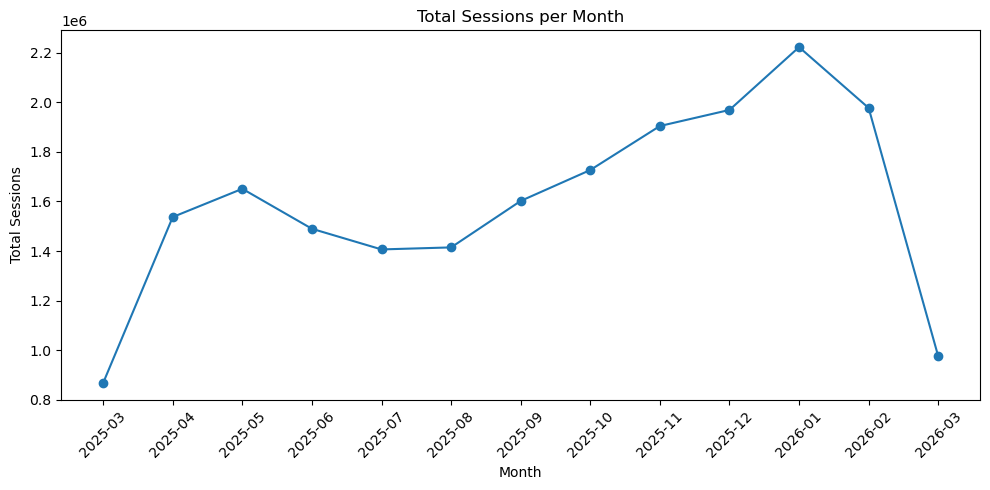

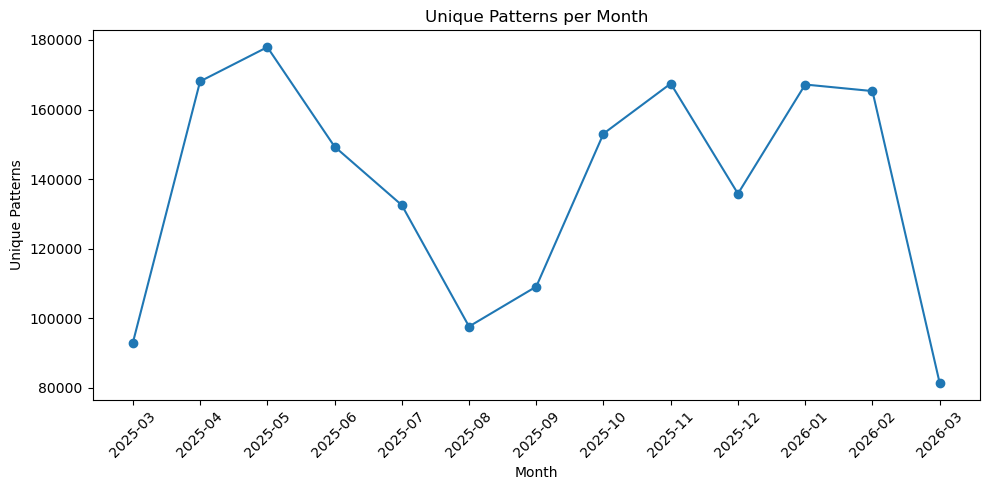

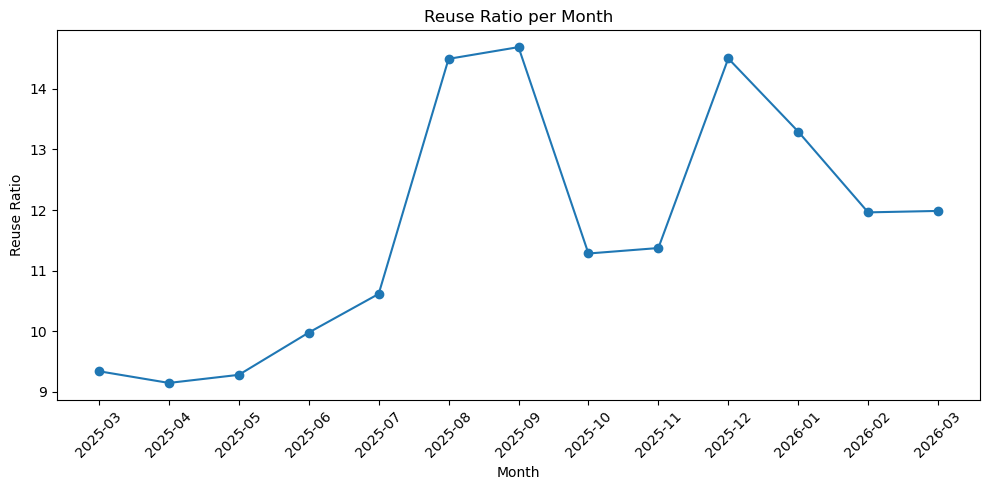

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(monthly_summary["month"], monthly_summary["total_sessions"], marker="o")
plt.xticks(rotation=45)
plt.title("Total Sessions per Month")
plt.xlabel("Month")
plt.ylabel("Total Sessions")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(monthly_summary["month"], monthly_summary["unique_patterns"], marker="o")
plt.xticks(rotation=45)
plt.title("Unique Patterns per Month")
plt.xlabel("Month")
plt.ylabel("Unique Patterns")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(monthly_summary["month"], monthly_summary["reuse_ratio"], marker="o")
plt.xticks(rotation=45)
plt.title("Reuse Ratio per Month")
plt.xlabel("Month")
plt.ylabel("Reuse Ratio")
plt.tight_layout()
plt.show()

In [5]:
for col in ["credentials", "allUserNames", "allUserPasswords", "urls", "httpRequests"]:
    non_empty = (df[col].astype(str) != "[]").sum()
    print(col, non_empty)

credentials 139319
allUserNames 139319
allUserPasswords 139319
urls 253745
httpRequests 1849251


Parse json fields safely

In [6]:
cols_keep = [
    "month",
    "protocol",
    "signature",
    "count",
    "unique_ips",
    "first_seen",
    "last_seen",
    "active_span_days",
    "days_seen",
    "category",
    "credentials",
    "urls",
    "httpRequests"
]

df = df[cols_keep].copy()

print(df.columns.tolist())
print(df.shape)

['month', 'protocol', 'signature', 'count', 'unique_ips', 'first_seen', 'last_seen', 'active_span_days', 'days_seen', 'category', 'credentials', 'urls', 'httpRequests']
(1849277, 13)


In [7]:
import json
import pandas as pd

def safe_load(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x

    x = str(x).strip()

    if x in ["", "[]", "{}", "nan", "None"]:
        return []

    try:
        return json.loads(x)
    except Exception:
        return []

df["credentials_parsed"] = df["credentials"].apply(safe_load)
df["urls_parsed"] = df["urls"].apply(safe_load)
df["httpRequests_parsed"] = df["httpRequests"].apply(safe_load)

print(df[["credentials_parsed", "urls_parsed", "httpRequests_parsed"]].head())

  credentials_parsed urls_parsed  \
0                 []          []   
1                 []          []   
2                 []          []   
3                 []          []   
4                 []          []   

                                 httpRequests_parsed  
0                                                 []  
1                                                 []  
2  [{'method': 'GET', 'status': 200, 'uri': '/', ...  
3  [{'method': 'GET', 'status': 200, 'uri': '/', ...  
4  [{'method': 'GET', 'status': 301, 'uri': '/.en...  


In [10]:

import numpy as np
from collections import Counter

def extract_http_features(row):
    reqs = row["httpRequests_parsed"]
    creds = row["credentials_parsed"]

    methods = []
    uris = []

    for r in reqs:
        if isinstance(r, dict):
            m = r.get("method")
            u = r.get("uri") if "uri" in r else r.get("uris")

            if m is not None:
                methods.append(str(m))
            if u is not None:
                uris.append(str(u))

    total_methods = len(methods)
    total_uris = len(uris)

    method_counter = Counter(methods)
    uri_counter = Counter(uris)

    method_probs = np.array(list(method_counter.values()), dtype=float)
    if method_probs.size > 0:
        method_probs = method_probs / method_probs.sum()
        method_entropy = -np.sum(method_probs * np.log(method_probs + 1e-12))
    else:
        method_entropy = 0.0

    uri_probs = np.array(list(uri_counter.values()), dtype=float)
    if uri_probs.size > 0:
        uri_probs = uri_probs / uri_probs.sum()
        uri_entropy = -np.sum(uri_probs * np.log(uri_probs + 1e-12))
    else:
        uri_entropy = 0.0

    return pd.Series({
        "request_count": len(reqs),
        "credential_used": int(len(creds) > 0),
        "unique_uri_count": len(set(uris)),
        "unique_method_count": len(set(methods)),
        "method_entropy": method_entropy,
        "uri_entropy": uri_entropy,
        "unique_uri_ratio": len(set(uris)) / max(1, total_uris)
    })

feature_df = df.apply(extract_http_features, axis=1)
df = pd.concat([df, feature_df], axis=1)

print(df[[
    "request_count",
    "credential_used",
    "unique_uri_count",
    "unique_method_count",
    "method_entropy",
    "uri_entropy",
    "unique_uri_ratio"
]].head())

   request_count  credential_used  unique_uri_count  unique_method_count  \
0            0.0              0.0               0.0                  0.0   
1            0.0              0.0               0.0                  0.0   
2            1.0              0.0               1.0                  1.0   
3            1.0              0.0               1.0                  1.0   
4            3.0              0.0               3.0                  2.0   

   method_entropy   uri_entropy  unique_uri_ratio  
0    0.000000e+00  0.000000e+00               0.0  
1    0.000000e+00  0.000000e+00               0.0  
2   -1.000089e-12 -1.000089e-12               1.0  
3   -1.000089e-12 -1.000089e-12               1.0  
4    6.365142e-01  1.098612e+00               1.0  


In [11]:
print(df[[
    "request_count",
    "credential_used",
    "unique_uri_count",
    "unique_method_count",
    "method_entropy",
    "uri_entropy",
    "unique_uri_ratio"
]].describe())

       request_count  credential_used  unique_uri_count  unique_method_count  \
count   1.849277e+06     1.849277e+06      1.849277e+06         1.849277e+06   
mean    2.191075e+01     7.533701e-02      1.703181e+01         1.185684e+00   
std     1.185964e+02     2.639344e-01      1.085739e+02         4.811036e-01   
min     0.000000e+00     0.000000e+00      0.000000e+00         0.000000e+00   
25%     1.000000e+00     0.000000e+00      1.000000e+00         1.000000e+00   
50%     2.000000e+00     0.000000e+00      2.000000e+00         1.000000e+00   
75%     1.000000e+01     0.000000e+00      6.000000e+00         1.000000e+00   
max     1.578100e+04     1.000000e+00      1.539300e+04         1.700000e+01   

       method_entropy   uri_entropy  unique_uri_ratio  
count    1.849277e+06  1.849277e+06      1.849277e+06  
mean     9.071764e-02  1.116481e+00      8.942970e-01  
std      2.300830e-01  1.427092e+00      2.440677e-01  
min     -1.000089e-12 -1.000089e-12      0.000000e+00  

In [12]:
monthly_summary = (
    df.groupby("month", as_index=False)
      .agg(
          total_sessions=("count", "sum"),
          unique_patterns=("signature", "nunique"),
          unique_ips=("unique_ips", "sum")
      )
)

monthly_summary["reuse_ratio"] = (
    monthly_summary["total_sessions"] / monthly_summary["unique_patterns"]
)

print(monthly_summary)

      month  total_sessions  unique_patterns  unique_ips  reuse_ratio
0   2025-03          867749            92927      213433     9.337964
1   2025-04         1537223           168095      360228     9.144966
2   2025-05         1651120           177947      411316     9.278718
3   2025-06         1489785           149330      354590     9.976462
4   2025-07         1406472           132501      333657    10.614803
5   2025-08         1414653            97587      267840    14.496326
6   2025-09         1602112           109061      291215    14.690054
7   2025-10         1726898           153063      351435    11.282269
8   2025-11         1904443           167460      367980    11.372525
9   2025-12         1969345           135791      326569    14.502765
10  2026-01         2222820           167189      394023    13.295253
11  2026-02         1977285           165305      375419    11.961435
12  2026-03          975070            81356      207222    11.985225


In [13]:
monthly_features = (
    df.groupby("month", as_index=False)
      .agg(
          avg_method_entropy=("method_entropy", "mean"),
          avg_uri_entropy=("uri_entropy", "mean"),
          avg_unique_uri_ratio=("unique_uri_ratio", "mean"),
          credential_pattern_ratio=("credential_used", "mean"),
          total_patterns=("signature", "nunique"),
          total_sessions=("count", "sum")
      )
)

print(monthly_features)

      month  avg_method_entropy  avg_uri_entropy  avg_unique_uri_ratio  \
0   2025-03            0.056543         1.200844              0.951387   
1   2025-04            0.120397         1.150006              0.871745   
2   2025-05            0.100382         1.100088              0.921023   
3   2025-06            0.128007         0.799089              0.803050   
4   2025-07            0.120602         1.316239              0.854137   
5   2025-08            0.088474         1.434596              0.920684   
6   2025-09            0.054970         1.005381              0.912137   
7   2025-10            0.051208         0.767936              0.914119   
8   2025-11            0.051232         1.239222              0.864849   
9   2025-12            0.089094         1.248963              0.904780   
10  2026-01            0.106650         1.143787              0.914874   
11  2026-02            0.101647         1.087454              0.912991   
12  2026-03            0.082348       

In [14]:
monthly_all = monthly_summary.merge(
    monthly_features.drop(columns=["total_sessions"]),
    on="month",
    how="left"
)

print(monthly_all)

      month  total_sessions  unique_patterns  unique_ips  reuse_ratio  \
0   2025-03          867749            92927      213433     9.337964   
1   2025-04         1537223           168095      360228     9.144966   
2   2025-05         1651120           177947      411316     9.278718   
3   2025-06         1489785           149330      354590     9.976462   
4   2025-07         1406472           132501      333657    10.614803   
5   2025-08         1414653            97587      267840    14.496326   
6   2025-09         1602112           109061      291215    14.690054   
7   2025-10         1726898           153063      351435    11.282269   
8   2025-11         1904443           167460      367980    11.372525   
9   2025-12         1969345           135791      326569    14.502765   
10  2026-01         2222820           167189      394023    13.295253   
11  2026-02         1977285           165305      375419    11.961435   
12  2026-03          975070            81356      2

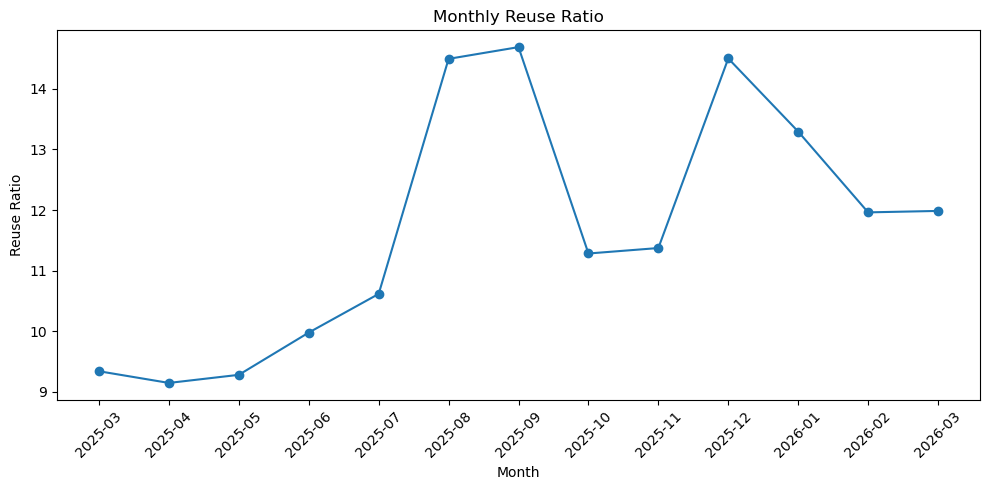

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(monthly_all["month"], monthly_all["reuse_ratio"], marker="o")
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Reuse Ratio")
plt.title("Monthly Reuse Ratio")
plt.tight_layout()
plt.show()

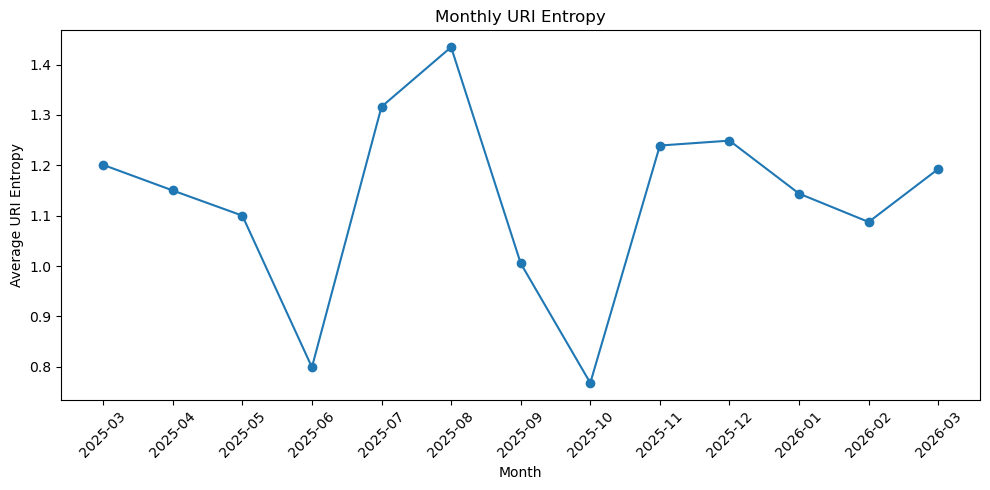

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_all["month"], monthly_all["avg_uri_entropy"], marker="o")
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Average URI Entropy")
plt.title("Monthly URI Entropy")
plt.tight_layout()
plt.show()

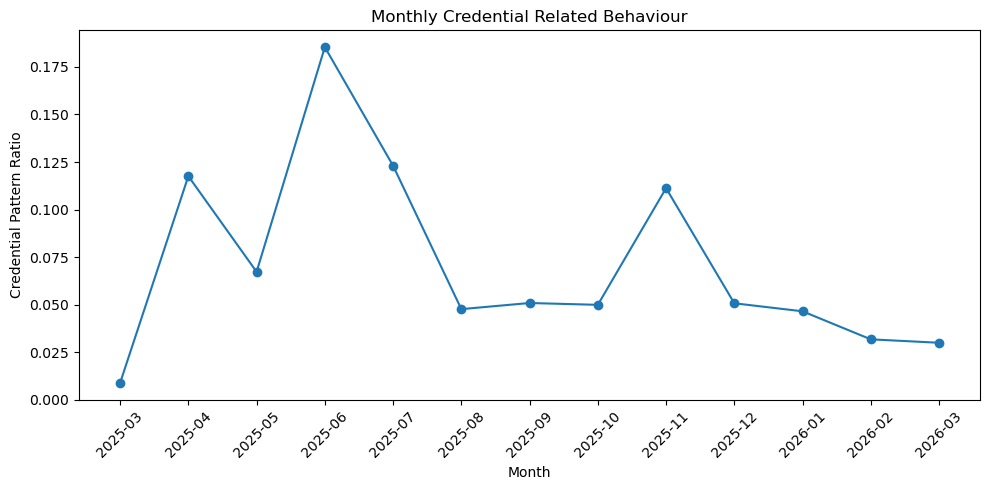

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_all["month"], monthly_all["credential_pattern_ratio"], marker="o")
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Credential Pattern Ratio")
plt.title("Monthly Credential Related Behaviour")
plt.tight_layout()
plt.show()

In [18]:
top_patterns = (
    df.sort_values(["month", "count"], ascending=[True, False])
      .groupby("month")
      .head(10)
)

print(top_patterns[[
    "month",
    "signature",
    "count",
    "unique_ips",
    "credential_used",
    "request_count",
    "method_entropy",
    "uri_entropy"
]].head(50))

          month                                          signature   count  \
0       2025-03  c33ca63a612700a00e23d764035ad7924482af0ad5e018...  261287   
1       2025-03  c33ca63a612700a00e23d764035ad7924482af0ad5e018...   80795   
2       2025-03  5cadd2ba7e7071cdf1a7eae82c86dab3aa787920c0fb95...   23036   
3       2025-03  06034475e5cb86a603709c0606489020bc3cf7d9ec4ea3...   22763   
4       2025-03  92ac86e73bd779ebf67a3a1ee400c4e6b71ad16895889e...   15951   
5       2025-03  35d9eb1ffecba4dab6302cfc0f0f8d9902b1a099a79f95...   15494   
6       2025-03  884a5d94edce4657acabe89796352c4d83243c72d8ec2e...   14425   
7       2025-03  12275c6f9fab27dca9dd8be46a0ca9204e50ff168d3e47...   12993   
8       2025-03  35d9eb1ffecba4dab6302cfc0f0f8d9902b1a099a79f95...   10405   
9       2025-03  b7703e0a19e0c506657310e933616e332d915f407abd0e...    9216   
97537   2025-04  c33ca63a612700a00e23d764035ad7924482af0ad5e018...  385721   
97538   2025-04  5cadd2ba7e7071cdf1a7eae82c86dab3aa787920c0fb95.

In [19]:
months = sorted(df["month"].unique())

seen = set()
novelty_rows = []

for m in months:
    current = set(df.loc[df["month"] == m, "signature"])
    new_patterns = current - seen

    novelty_rows.append({
        "month": m,
        "total_patterns": len(current),
        "new_patterns": len(new_patterns),
        "novelty_rate": len(new_patterns) / max(1, len(current))
    })

    seen |= current

novelty_df = pd.DataFrame(novelty_rows)
print(novelty_df)

      month  total_patterns  new_patterns  novelty_rate
0   2025-03           92927         92927      1.000000
1   2025-04          168095        150401      0.894738
2   2025-05          177947        155727      0.875131
3   2025-06          149330        122952      0.823358
4   2025-07          132501        108576      0.819435
5   2025-08           97587         80079      0.820591
6   2025-09          109061         90324      0.828197
7   2025-10          153063        129735      0.847592
8   2025-11          167460        143419      0.856437
9   2025-12          135791        109890      0.809258
10  2026-01          167189        139481      0.834271
11  2026-02          165305        138271      0.836460
12  2026-03           81356         65233      0.801822


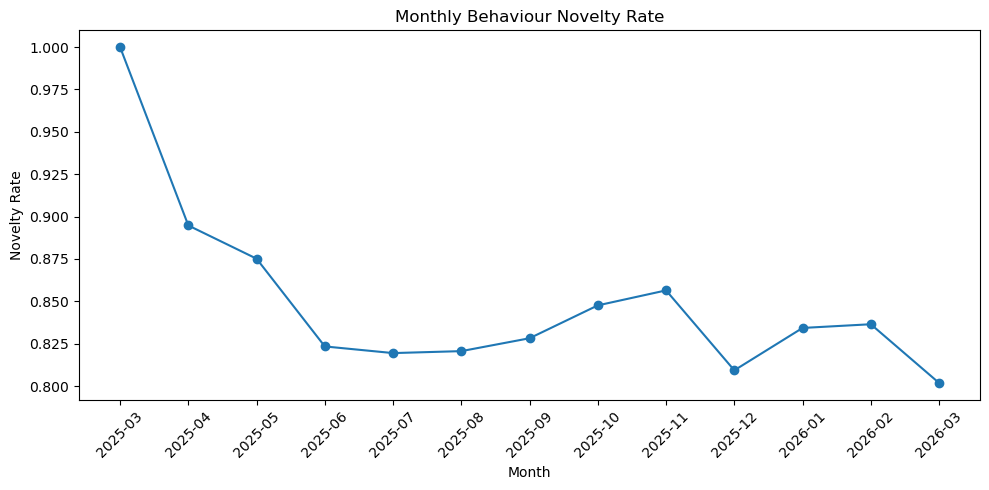

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(novelty_df["month"], novelty_df["novelty_rate"], marker="o")
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Novelty Rate")
plt.title("Monthly Behaviour Novelty Rate")
plt.tight_layout()
plt.show()

In [21]:
monthly_all.to_csv("../data/honeypot/http_https_monthly_patterns/monthly_all_summary.csv", index=False)
novelty_df.to_csv("../data/honeypot/http_https_monthly_patterns/monthly_novelty.csv", index=False)
top_patterns.to_csv("../data/honeypot/http_https_monthly_patterns/top_patterns_per_month.csv", index=False)